<a href="https://colab.research.google.com/github/sde2424242424-coder/2026_spring_assignments/blob/main/Books_to_Scrape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Books to Scrape

이 프로젝트에서는 Python, Requests, BeautifulSoup을 사용하여 Books to Scrape 웹사이트에서 도서 데이터를 수집하였다.

먼저 메인 페이지에서 20개의 도서 제목을 추출하였다. 이후 첫 번째부터 열 번째 카탈로그 페이지까지 총 100개의 제목을 수집하였다.

그 다음, 처음 10개의 카테고리에서 각각 10권의 도서를 수집하였으며, 카테고리 이름, 도서 제목, 가격 정보를 포함하였다.

가격 데이터는 분석을 위해 정제(cleaning)한 후 숫자형으로 변환하였다.

이후 데이터셋을 정렬하여 가장 비싼 도서 상위 10권을 도출하였다.

마지막으로 Q-Q 플롯과 Shapiro-Wilk 검정을 통해 도서 가격 분포를 평가하였다.

이 결과를 바탕으로 가격 분포의 정규성 여부를 통계적으로 해석할 수 있다.

In [2]:
import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from scipy.stats import shapiro
import statsmodels.api as sm

BASE_URL = "https://books.toscrape.com/"

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0"
})

In [3]:
def get_soup(url):
    response = session.get(url, timeout=10)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")

In [4]:
def clean_price(price_text):
    numeric = re.sub(r"[^0-9.]", "", price_text)
    return float(numeric)

In [5]:
def get_first_20_titles():
    soup = get_soup(BASE_URL)
    books = soup.select("article.product_pod h3 a")

    titles = []
    for book in books[:20]:
        titles.append(book["title"])

    return pd.DataFrame({"Title": titles})

In [6]:
def get_first_100_titles():
    titles = []

    for page in range(1, 11):
        page_url = urljoin(BASE_URL, f"catalogue/page-{page}.html")
        soup = get_soup(page_url)

        books = soup.select("article.product_pod h3 a")
        for book in books:
            titles.append(book["title"])

        time.sleep(0.2)

    return pd.DataFrame({
        "No": range(1, len(titles) + 1),
        "Title": titles
    })

In [7]:
def get_first_10_categories():
    soup = get_soup(BASE_URL)
    category_links = soup.select("ul.nav-list ul li a")[:10]

    categories = []
    for tag in category_links:
        name = tag.get_text(strip=True)
        link = urljoin(BASE_URL, tag["href"])
        categories.append((name, link))

    return categories

In [8]:
def scrape_category_books(limit_per_category=10):
    rows = []
    categories = get_first_10_categories()

    for category_name, category_url in categories:
        soup = get_soup(category_url)
        products = soup.select("article.product_pod")[:limit_per_category]

        for product in products:
            a_tag = product.select_one("h3 a")
            price_tag = product.select_one("p.price_color")

            title = a_tag["title"]
            price_text = price_tag.get_text(strip=True)
            price_value = clean_price(price_text)

            rows.append({
                "Category": category_name,
                "Title": title,
                "Price": price_text,
                "Price_Numeric": price_value
            })

        time.sleep(0.2)

    return pd.DataFrame(rows)

In [9]:
def show_top_10_expensive(df):
    return df.sort_values("Price_Numeric", ascending=False).head(10)

In [10]:
def normality_analysis(df):
    prices = df["Price_Numeric"]

    print("Descriptive Statistics")
    print(prices.describe())
    print()

    stat, p_value = shapiro(prices)
    print(f"Shapiro-Wilk statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Result: price data can be considered approximately normal.")
    else:
        print("Result: price data does NOT follow a normal distribution.")

    plt.figure(figsize=(7, 7))
    sm.qqplot(prices, line="45", fit=True)
    plt.title("Q-Q Plot of Book Prices")
    plt.show()

### 1) 처음 20개의 제목

In [11]:
df_20_titles = get_first_20_titles()
print("First 20 book titles")
print(df_20_titles)

First 20 book titles
                                                Title
0                                A Light in the Attic
1                                  Tipping the Velvet
2                                          Soumission
3                                       Sharp Objects
4               Sapiens: A Brief History of Humankind
5                                     The Requiem Red
6   The Dirty Little Secrets of Getting Your Dream...
7   The Coming Woman: A Novel Based on the Life of...
8   The Boys in the Boat: Nine Americans and Their...
9                                     The Black Maria
10     Starving Hearts (Triangular Trade Trilogy, #1)
11                              Shakespeare's Sonnets
12                                        Set Me Free
13  Scott Pilgrim's Precious Little Life (Scott Pi...
14                          Rip it Up and Start Again
15  Our Band Could Be Your Life: Scenes from the A...
16                                               Olio
17  Mes

### 2) 처음 100개의 제목

In [12]:
df_100_titles = get_first_100_titles()
print("\nFirst 100 book titles")
print(df_100_titles)


First 100 book titles
      No                                              Title
0      1                               A Light in the Attic
1      2                                 Tipping the Velvet
2      3                                         Soumission
3      4                                      Sharp Objects
4      5              Sapiens: A Brief History of Humankind
..   ...                                                ...
195  196                                  Eureka Trivia 6.0
196  197  Drive: The Surprising Truth About What Motivat...
197  198            Done Rubbed Out (Reightman & Bailey #1)
198  199                  Doing It Over (Most Likely To #1)
199  200  Deliciously Ella Every Day: Quick and Easy Rec...

[200 rows x 2 columns]


### 3) 10개 카테고리 × 10권의 책

In [13]:
df_books = scrape_category_books(limit_per_category=10)
print("\nBooks dataset")
print(df_books)


Books dataset
     Category                                              Title    Price  \
0      Travel                            It's Only the Himalayas  Â£45.17   
1      Travel  Full Moon over Noahâs Ark: An Odyssey to Mou...  Â£49.43   
2      Travel  See America: A Celebration of Our National Par...  Â£48.87   
3      Travel  Vagabonding: An Uncommon Guide to the Art of L...  Â£36.94   
4      Travel                               Under the Tuscan Sun  Â£37.33   
..        ...                                                ...      ...   
95  Childrens                  Walt Disney's Alice in Wonderland  Â£12.96   
96  Childrens                                       Twenty Yawns  Â£22.08   
97  Childrens                                          Rain Fish  Â£23.57   
98  Childrens                                    Once Was a Time  Â£18.28   
99  Childrens                              Luis Paints the World  Â£53.95   

    Price_Numeric  
0           45.17  
1           49.43  


### 4) 가장 비싼 책 10권

In [14]:
top10 = show_top_10_expensive(df_books)
print("\nTop 10 most expensive books")
print(top10[["Category", "Title", "Price", "Price_Numeric"]])


Top 10 most expensive books
              Category                                              Title  \
46            Classics                                            Candide   
51          Philosophy       The Death of Humanity: and the Case for Life   
93           Childrens  The White Cat and the Monk: A Retelling of the...   
70      Womens Fiction  I Had a Nice Time And Other Lies...: How to fi...   
47            Classics                                        Animal Farm   
7               Travel                   A Year in Provence (Provence #1)   
12             Mystery                                The Past Never Ends   
92           Childrens                    The Secret of Dreadwillow Carse   
66             Romance                   Suddenly in Love (Lake Haven #1)   
22  Historical Fiction            A Flight of Arrows (The Pathfinders #2)   

      Price  Price_Numeric  
46  Â£58.63          58.63  
51  Â£58.11          58.11  
93  Â£58.08          58.08  
70  Â£5

### 5) 정규성 검정

Descriptive Statistics
count    100.000000
mean      34.593500
std       15.323483
min       10.160000
25%       19.922500
50%       34.250000
75%       49.010000
max       58.630000
Name: Price_Numeric, dtype: float64

Shapiro-Wilk statistic: 0.9158
p-value: 0.0000
Result: price data does NOT follow a normal distribution.


<Figure size 700x700 with 0 Axes>

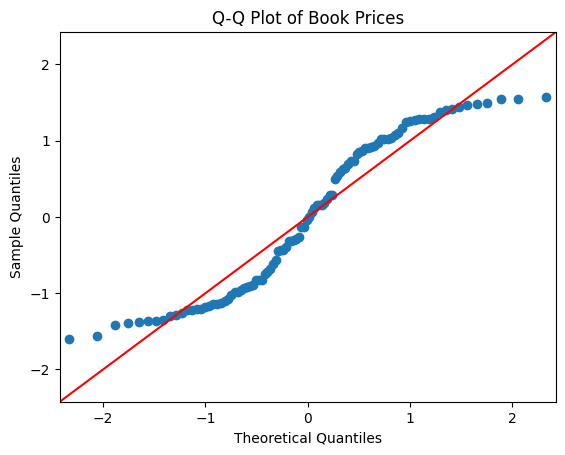

In [15]:
normality_analysis(df_books)